# STUDENT NUMBER: 2575686N

# Pre-processing

The Weizmann dataset consists of 93 videos across 10 different movement categories. Each video is at least 36 frames long and has a resolution of 180x140 pixels.

## Split in training, validation, test set

The dataset is divided into training, validation, and test sets. The training set is used to adjust the network's weights, while the validation set evaluates the impact of these changes on unseen data. The test set is exclusively used for the final accuracy assessment and is never seen during training.

To achieve this split, one video from each group was randomly selected for the test and validation sets, with the remaining videos used for training. This resulted in:

- Training set: 73 videos, 7-8 per movement
- Validation set: 10 videos, 1 per movement
- Test set: 10 videos, 1 per movement

## Silhouette extraction
Videos are provided in RGB format, but colors were deemed unnecessary. Instead, relevant information was extracted before feeding into the network. Two approaches were considered:

1. Foreground Extraction: Pixels of the foreground are set to 1, and background pixels to 0, resulting in silhouettes of the person.

2. Moving Pixels Extraction: Pixels that change between frames are set to 1, and static pixels to 0, creating "movement silhouettes."

Using binary images reduces the number of channels, improving training time. Both methods pre-filter important video information. Approach (2) performed better in initial tests and was used going forward, enhancing invariance to lighting, colors, background, and clothing.


Picture of a moving silhouette for a running person:
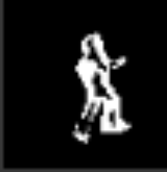

## Data Augmentation

Due to the small sample size, random transformations were applied to increase the dataset:

- Random Frame Selection: 36 consecutive frames are taken from each video at a random start point.
- Random Cropping: Frames are cropped from 180x144 to 128x128 pixels.
- Vertical Flipping: Videos are flipped vertically with a 50% chance.
- Random Rotation: Videos are rotated between -20 and +20 degrees.

$$
(100-36) * (180-128) * (144-128) * 2 * 40 = 4,259,840
$$

These transformations can create up to 4,259,840 variations for a 100-frame video, adding invariance to rotation and subject location.


Many of these videos might be quite similar, as changes in 1 px, 1° or 1 frame are minor. However, it still allows some form of data augmentation, with the exact same images unlikely to be used again as 10,000 samples from 73 videos of 4M different variations were drawn.

## Scaling
After cropping videos from 180x144 to 128x128 pixels, they were further scaled down to 64x64 pixels, as it was found to improve training times, while still carrying all important information.


## Binarization
After the silhouette extraction, pixels are either 255 or 0. By utilizing the rotation transformation used, some pixels were numbers in between those. For better training and more cohesive input data, all pixels are normalized to either 0 or 1, depending on a set threshold.


---



# Architecture
The final architecture consists of convolutional layers, followed by a GRU layer, again followed by fully connected layers. This proved to be a well-working setup.

The initial neural network consisted solely of RNN layers followed by fully connected layers. RNNs were chosen for their "memory" capabilities, but they did not achieve high accuracy, likely due to the loss of spatial information when feeding input data. To address this, a convolutional layer was added before the RNN, with additional layers added later, significantly improving performance. The RNN was then replaced with a GRU, which better mitigates the vanishing gradient problem. Although LSTM was tested, it did not offer significant improvements over GRU, so GRU was retained for its simpler structure, keeping the model efficient.


Final Architecture:

1. Convolutional Layers

    Used to extract spatial information from the input frames. This is helpful to identify where the person is in the image and how it is moving. ReLU activation functions were used as they are a common choice that proofed to be suitable during testing.

  - Conv1
  - Conv2
  - Conv3

2. Max Pooling

    Max Pooling is used to scale down the dimensionalty.

3. GRU Layer

    The GRU layer is used to make sense of consecutive frames. It allows to "connect" the spatial features of different frames together, identifying motions. It "makes sense" of consecutive information and can "memorise" what happened in frames before. GRU was preferred over a "normal" RNN as it mitigates the vanishing gradient problem. A 2-time stacked GRU was used as it showed to improve performance, allowing to extract more detailed information.

4. Fully Connected Layers

    These layers make sense of the information extracted by the GRU layer, allowing to identify probabilities for the 10 movement classes possible. They translate the GRU output into th emost likely movement class. Adding a third FC layer, allowed to push the accuracy from about 95% to 99%. Adding further fully connected layers might further improve this. ReLU activation functions were used for similar reasons as the ones for the Convolutional Layers.

  - FC1
  - FC2
  - FC3


---


# Loss

Cross-entropy loss was used for training the model. This is a common method used for multi-class classification problems, which this example is (deciding between 10 different classes of motions). The loss function proved to work during the entirety of building this NN and was hence kept.


---



# Training

The model is trained on the training set, a set of 73 videos which are augemnted using a data loader and the transformations described above. The final model was trained for 21 epochs (as stopped by the scheduler), on 10000 samples with a batch size of 32 (the batch size used is a common good practice).

The step size starts at 0.0001, decreasing as the scheduler moves forward. Other step sizes were tried (1.000 - 0.000001), but none have proven to be working better than 0.0001. To compare them, convergence graphs were analysed next to each other. The chosen 0.0001, together with a scheduler, showed to be a sweet spot.

A scheduler was used to half the step size every 10 epochs, as this proved to be a quite good approach. Training the model without a scheduler was tried first, but this led to worse results. The scheduler was changed to different numbers of epochs (30 and 5) but 10 proved to be a decent sweet spot for convergence.

For each epoch, the loss for the validation data is calculated as well. Using "early stopping" the training is stopped if the validation loss does not improve for 5 epochs, which should lower the risk of overfitting. Stopping the model earlier showed to indeed offer better results for the validation data classification.

The images below show how the loss for both training and validation data changed over the training epochs. It shows the model converging as training proceeds. These graphs are for the final model provided.

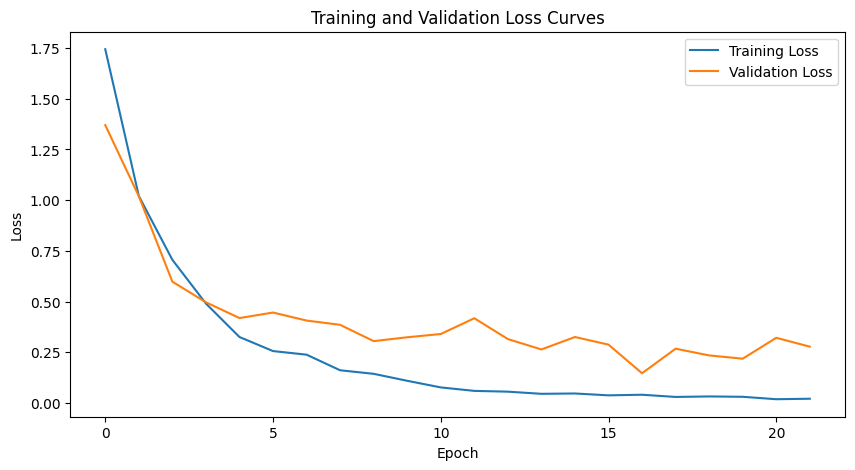

---



# Classification & Testing

To verify the model to work well, a test dataset of 10 videos, yet unseen by the model, were augmented using the same transformations applied to the training set. It was also tested to apply only the silhouette extraction, cropping & frame extraction (as this data does not need to be augmented), however this lead to worse classifiation results for the validation set. Hence, both validation and test data was transformed in the exact same way as the training data was.

The model was then to classify various samples to estimate its accuracy in classifying the videos correctly. Further, a confusion matrix was created, to determine which motions were commonly confused with one another.

The general performance was found to be ~99.5% accuracy. The confusion matrix shows that mostly videos of motion 9 (skipping) were confused to be videos of class 1 (running) and 2 (jumping). This makes sense, as skipping is somewhat a combination of these two motions.

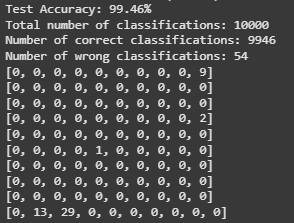

The graph below shows one transformation of each of the 10 test videos, together with the true and predicted label.

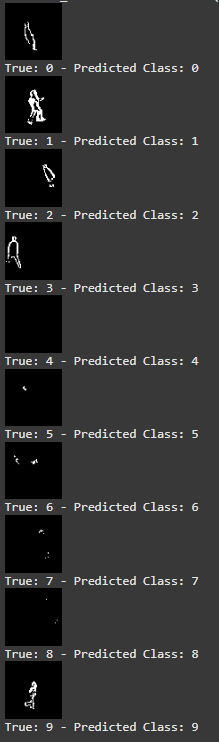

---

# Generalisation
I do not expect this model to generalise very well. I believe due to the limited dataset this is almost impossible. Applying the transformations as described, allows to somewhat augment the data, however, starting from only 73 videos, limits what is achievable. The model has good performance on similar data (same camera, similar angle, etc.). But I do not think that other videos of other recordings will have the same results. It might still perform okay, but I do not expect to to reach an accuracy of correctly classifying videos with a 99% accuracy as it does for the test data chosen in this example.

---

# Further Steps

While the model already works well for classifying motions from the sample videos, further improvements could be made.

1. The videos could be adjusted to different speeds, skipping or adding frames. This could make the model more robust for motions of varying speeds.

2. The videos are currently only rotated in ranges of +/-20°. This range could further be extended. However, it is likely that those are the actual angles of videos, as cameras that are more tilted are unlikely.

3. At the moment, all videos are cropped from 180x144 to 128x128 pixels. Further, all videos seem to be filmed from a similar distance to the subject. To add more "distance invariance", the videos could be "zoomed in" or out improve this behaviour.

4. Adding noise. Sometimes, adding noise to videos help to train the model more sucessfully, as it learns to "only" focus on important information. This could also be tested for this model

5. Adding random obstructions. Pixel sections could be removed from the videos to simulate objects obstructing the view. This could e.g. simulate cars, pillars etc. This might add to the robustness of the model

6. Adding more layers could improve the model further. However, it should also be kept as simple as possible.

If I had more time and a more powerful device to run my training on (such as the A100), I would probably add more layers, further trying more implementations such as varying activation functions. The confusion matrix also shows, that most confusions happen at class 9 (skipping), which is commonly identified as class 1 (running) or 2 (jumping). This confusion does make sense, as skipping as a motion that combines both running and jumping, but would also be an interesting topic to look into. Why does this misclassification happen? We specifically for skipping? In doing so, the performance of the model could be further improved.

---

In [1]:
# RUN ALL IMPORTS

import os
import random
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
from google.colab import drive
from google.colab.patches import cv2_imshow
from scipy import ndimage
import torchvision.transforms.functional as F
from matplotlib import pyplot as plt

In [2]:
# LOAD VIDEOS FROM GITHUB


# Function to load videos from a specified directory
def load_videos(root_dir='videos'):
    videos = {}
    class_labels = {
        'walk': 0, 'run': 1, 'jump': 2, 'side': 3, 'bend': 4,
        'wave1': 5, 'wave2': 6, 'pjump': 7, 'jack': 8, 'skip': 9
    }

    for class_name in class_labels:
        videos[class_name] = []

    for class_name in class_labels:
        class_dir = os.path.join(root_dir, class_name)
        if os.path.exists(class_dir):
            for video_file in os.listdir(class_dir):
                if video_file.endswith('.avi'):
                    video_path = os.path.join(class_dir, video_file)
                    cap = cv2.VideoCapture(video_path)
                    frames = []
                    if cap.isOpened():
                        while True:
                            ret, frame = cap.read()
                            if not ret:
                                break
                            frames.append(frame)
                        cap.release()
                        videos[class_name].append(frames)
                    else:
                        print(f"Error: Could not open video {video_path}")
    return videos


repo_dir = 'Deep_Learning_AE'

if not os.path.exists(repo_dir):
    !git clone https://github.com/RaphaelNekam/Deep_Learning_AE.git
else:
    print(f"The repository '{repo_dir}' is already cloned.")


# Load default videos
train_videos = load_videos(f'/content/{repo_dir}/datasets/train_videos')
test_videos = load_videos(f'/content/{repo_dir}/datasets/test_videos')
validation_videos = load_videos(f'/content/{repo_dir}/datasets/validation_videos')

counter = 0

for key in train_videos:
  counter += len(train_videos[key])

print(f"Total number of train videos: {counter} (should be 73)")

counter = 0

for key in test_videos:
  counter += len(test_videos[key])

print(f"Total number of test videos: {counter} (should be 10)")

counter = 0

for key in validation_videos:
  counter += len(validation_videos[key])

print(f"Total number of validation videos: {counter} (should be 10)")


Cloning into 'Deep_Learning_AE'...
remote: Enumerating objects: 150, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 150 (delta 0), reused 0 (delta 0), pack-reused 149 (from 3)
Receiving objects: 100% (150/150), 568.48 MiB | 43.46 MiB/s, done.
Resolving deltas: 100% (4/4), done.
Updating files: 100% (101/101), done.
Total number of train videos: 73 (should be 73)
Total number of test videos: 10 (should be 10)
Total number of validation videos: 10 (should be 10)


In [3]:
def extract_silhouette_from_two_frames(frame1, frame2):
    diff = cv2.absdiff(frame1, frame2)
    gray_diff = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    _, movingPixels = cv2.threshold(gray_diff, 30, 255, cv2.THRESH_BINARY)
    return movingPixels

def random_vertical_flip(frames, flip_probability=0.5):
    if random.random() < flip_probability:
        return [cv2.flip(frame, 1) for frame in frames]
    return frames

def random_rotation(frames, rotation_limit=(-30, 30), device='cuda'):
    angle = random.randint(rotation_limit[0], rotation_limit[1])
    frames_tensor = torch.from_numpy(np.stack(frames)).to(device)
    rotated_frames = F.rotate(frames_tensor, angle, interpolation=F.InterpolationMode.BILINEAR)
    return rotated_frames

def random_crop(frames, crop_size=(128, 128)):
    height, width = frames[0].shape[:2]
    top = random.randint(0, height - crop_size[0])
    left = random.randint(0, width - crop_size[1])
    return [frame[top:top + crop_size[0], left:left + crop_size[1]] for frame in frames]

def random_frames(frames, length=50):
    if len(frames) < length:
        return frames
    start = random.randint(0, len(frames) - length)
    return frames[start:start + length]

def binarize_frames(frames, threshold=255/2):
    return (frames > threshold).to(torch.uint8)

def scale_down_binary_frames(frames, size=(64, 64)):
    return [cv2.resize(frame, size, interpolation=cv2.INTER_AREA) for frame in frames]

def randomly_transform_video(default_video):
    rf = random_frames(default_video, 36)
    # transformed_frames = extract_silhouettes(random_frames) # extract foreground
    transformed_frames = [extract_silhouette_from_two_frames(rf[i], rf[i + 1]) for i in range(len(rf) - 1)] # extract moving pixels
    transformed_frames = random_crop(transformed_frames)
    transformed_frames = random_vertical_flip(transformed_frames)
    transformed_frames = scale_down_binary_frames(transformed_frames)
    transformed_frames = random_rotation(transformed_frames, (-20, 20))
    return binarize_frames(transformed_frames)


def extract_silhouettes(frames):
    frames_tensor = torch.tensor(np.array(frames), dtype=torch.float32, device=device)
    frames_gray = 0.2989 * frames_tensor[:, :, :, 0] + 0.5870 * frames_tensor[:, :, :, 1] + 0.1140 * frames_tensor[:, :, :, 2]
    background = torch.mean(frames_gray[:2], dim=0, keepdim=True)
    foreground = torch.abs(frames_gray - background)
    silhouettes = (foreground > 30).to(torch.uint8) * 255
    silhouettes_np = silhouettes.cpu().numpy()
    return silhouettes_np

def pick_random_video(videos):
    class_labels = {
        'walk': 0, 'run': 1, 'jump': 2, 'side': 3, 'bend': 4,
        'wave1': 5, 'wave2': 6, 'pjump': 7, 'jack': 8, 'skip': 9
    }
    random_label = random.choice(list(class_labels.keys()))
    random_video = videos[random_label][random.randint(0, len(videos[random_label]) - 1)]
    return {"label": class_labels[random_label], "video": random_video}

In [4]:
def display_video_list(frames):
  for frame in frames:
    display_image_list(frame)

def display_video_tensor(frames):
  for frame in frames:
    display_tensor_image(frame)

def display_tensor_image(tensor_image):
    if tensor_image.is_cuda:
        tensor_image = tensor_image.cpu()
    if tensor_image.dim() == 3:
        tensor_image = tensor_image.squeeze(0)
    numpy_image = tensor_image.numpy() * 255.0
    numpy_image = numpy_image.astype(np.uint8)
    cv2_imshow(numpy_image)


def display_image_list(image):
    if image.max() <= 1.0:
        image = (image * 255.0).astype(np.uint8)
    else:
        image = image.astype(np.uint8)
    cv2_imshow(image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

In [5]:
# Hyperparameters
input_channels = 1
num_samples = 10000
num_frames = 35
height = 64
width = 64
batch_size = 32
num_epochs = 200
input_size = height * width
hidden_size = 256
output_size = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# DATA LOADERS

class RandomTrainVideoDataset(Dataset):
    def __init__(self, num_samples, num_frames, height, width):
        self.num_samples = num_samples
        self.num_frames = num_frames
        self.height = height
        self.width = width

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        random_video = pick_random_video(train_videos)
        transformed_video = randomly_transform_video(random_video["video"])
        transformed_video = torch.tensor(transformed_video, dtype=torch.float32)  # Convert to tensor
        transformed_video = transformed_video.view(self.num_frames, 1, self.height, self.width)  # Ensure shape is (num_frames, height, width)
        class_counter[random_video["label"]] += 1
        return transformed_video, random_video["label"]


class RandomValidationVideoDataset(Dataset):
    def __init__(self, num_samples, num_frames, height, width):
        self.num_samples = num_samples
        self.num_frames = num_frames
        self.height = height
        self.width = width

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        random_video = pick_random_video(validation_videos)
        transformed_video = randomly_transform_video(random_video["video"])
        transformed_video = torch.tensor(transformed_video, dtype=torch.float32)  # Convert to tensor
        transformed_video = transformed_video.view(self.num_frames, 1, self.height, self.width)  # Ensure shape is (num_frames, height, width)
        return transformed_video, random_video["label"]

class RandomTestVideoDataset(Dataset):
    def __init__(self, num_samples, num_frames, height, width):
        self.num_samples = num_samples
        self.num_frames = num_frames
        self.height = height
        self.width = width

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        random_video = pick_random_video(test_videos)
        transformed_video = randomly_transform_video(random_video["video"])
        transformed_video = torch.tensor(transformed_video, dtype=torch.float32)  # Convert to tensor
        transformed_video = transformed_video.view(self.num_frames, 1, self.height, self.width)  # Ensure shape is (num_frames, height, width)
        return transformed_video, random_video["label"]


# Create dataset and dataloader
dataset = RandomTrainVideoDataset(num_samples, num_frames, height, width)
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

val_dataset = RandomValidationVideoDataset(num_samples, num_frames, height, width)
val_data_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

test_dataset = RandomTestVideoDataset(num_samples, num_frames, height, width)
test_data_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

Using device: cuda


In [6]:
# MODEL

class CNNGRU(nn.Module):
    def __init__(self, input_channels, hidden_size, output_size, input_height, input_width):
        super(CNNGRU, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=input_channels, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.cnn_output_size = 256 * (input_height // 8) * (input_width // 8)  # Adjust based on pooling

        self.gru = nn.GRU(input_size=self.cnn_output_size, hidden_size=hidden_size, num_layers=2, batch_first=True, dropout=0.3)

        self.fc1 = nn.Linear(hidden_size, hidden_size // 2)
        self.fc2 = nn.Linear(hidden_size // 2, hidden_size // 4)
        self.fc3 = nn.Linear(hidden_size // 4, hidden_size // 8)
        self.fc4 = nn.Linear(hidden_size // 8, output_size)

    def forward(self, x):
        batch_size, seq_length, channels, height, width = x.size()

        x = x.view(batch_size * seq_length, channels, height, width)

        # convolutional layers
        x = self.pool(nn.functional.relu(self.conv1(x)))
        x = self.pool(nn.functional.relu(self.conv2(x)))
        x = self.pool(nn.functional.relu(self.conv3(x)))

        x = x.view(batch_size, seq_length, -1)

        # GRU
        out, _ = self.gru(x)

        # Use the last output of the GRU
        out = out[:, -1, :]

        # fully connected layers
        out = nn.functional.relu(self.fc1(out))
        out = nn.functional.relu(self.fc2(out))
        out = nn.functional.relu(self.fc3(out))
        out = self.fc4(out)

        return out

model = CNNGRU(input_channels=input_channels, hidden_size=hidden_size, output_size=output_size, input_height=height, input_width=width).to(device)

In [7]:
# LOAD PRETRAINED MODEL
path = '/content/Deep_Learning_AE/models/CNNGRU_21_epochs_patience_5.pth'
# Use map_location to load the model on the CPU
model = CNNGRU(input_channels=input_channels, hidden_size=hidden_size, output_size=output_size, input_height=height, input_width=width).to(device)
model.load_state_dict(torch.load(path, map_location=torch.device('cpu')))

#If you intend to use a GPU if available, then do the following.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

<ipython-input-7-881ca167ed0d>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location=torch.device('cpu')))


CNNGRU(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (gru): GRU(16384, 256, num_layers=2, batch_first=True, dropout=0.3)
  (fc1): Linear(in_features=256, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (fc4): Linear(in_features=32, out_features=10, bias=True)
)

In [8]:
# TRAIN MODEL

train_flag = False



if not train_flag:
  print("Training not started. train_flag is deactivated")

else:
  class_counter = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

  # Initialize the model, loss function, and optimizer
  criterion = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

  scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)


  # Early stopping parameters
  patience = 5
  best_val_loss = float('inf')
  epochs_no_improve = 0

  train_losses = []
  val_losses = []

  # Training loop
  for epoch in range(num_epochs):
      epoch_train_losses = []
      model.train()
      for frames, labels in data_loader:
          frames, labels = frames.to(device), labels.to(device) #move data to gpu.
          # Forward pass
          outputs = model(frames)
          loss = criterion(outputs, labels.view(-1))  # Reshape labels for loss calculation

          # Backward pass and optimization
          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

          epoch_train_losses.append(loss.item())

      train_losses.append(sum(epoch_train_losses) / len(epoch_train_losses))

      model.eval()
      val_loss = 0.0
      with torch.no_grad():
          for frames, labels in val_data_loader:
              frames, labels = frames.to(device), labels.to(device)
              outputs = model(frames)
              loss = criterion(outputs, labels.view(-1))
              val_loss += loss.item()
      val_losses.append(val_loss / len(val_data_loader))

      scheduler.step()

      # Early stopping check
      if val_losses[-1] < best_val_loss:
          best_val_loss = val_losses[-1]
          epochs_no_improve = 0
      else:
          epochs_no_improve += 1

      if epochs_no_improve == patience:
          print(f'Early stopping! No improvement in validation loss for {patience} epochs.')
          break #exit the training loop.

      print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_losses[-1]:.4f}, Validation Loss: {val_losses[-1]:.4f}, Learning Rate: {scheduler.get_last_lr()}')



  # Plotting convergence curves
  plt.figure(figsize=(10, 5))
  plt.plot(train_losses, label='Training Loss')
  plt.plot(val_losses, label='Validation Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Training and Validation Loss Curves')
  plt.legend()
  plt.show()

  print(class_counter)

Training not started. train_flag is deactivated


In [9]:
# EVALUATE MODEL


def evaluate_model(model, test_loader, device, total, correct):
    model.eval()

    with torch.no_grad():
        for frames, labels in test_loader:
            frames, labels = frames.to(device), labels.to(device)

            frames = torch.tensor(frames)
            outputs = model(frames)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            for true_label, pred_label in zip(labels, predicted):
                if true_label != pred_label:
                    mistakes_matrix[true_label.item()][pred_label.item()] += 1

    accuracy = 100 * correct / total
    return accuracy, correct, total

mistakes_matrix = [[0] * output_size for _ in range(output_size)]

for i in range(1):
  correct = 0
  total = 0
  test_accuracy, correct, total = evaluate_model(model, test_data_loader, device, total, correct)

  print(f'Test Accuracy: {test_accuracy:.2f}%')
  print(f'Total number of classifications: {total}')
  print(f'Number of correct classifications: {correct}')
  print(f'Number of wrong classifications: {total-correct}')

for line in mistakes_matrix:
  print(line)


<ipython-input-5-8cdf2bfbbd72>:67: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  transformed_video = torch.tensor(transformed_video, dtype=torch.float32)  # Convert to tensor
<ipython-input-9-905263859096>:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  frames = torch.tensor(frames)


Test Accuracy: 99.32%
Total number of classifications: 10000
Number of correct classifications: 9932
Number of wrong classifications: 68
[0, 0, 0, 1, 0, 0, 0, 0, 0, 16]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 24, 25, 0, 0, 0, 0, 0, 0, 0]


<ipython-input-10-3b4be73e1aea>:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  frames_tensor = torch.tensor(frames, dtype=torch.float32).unsqueeze(1).to(device)


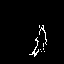

True: 0 - Predicted Class: 0


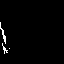

True: 1 - Predicted Class: 1


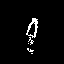

True: 2 - Predicted Class: 2


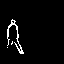

True: 3 - Predicted Class: 3


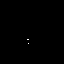

True: 4 - Predicted Class: 4


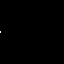

True: 5 - Predicted Class: 5


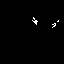

True: 6 - Predicted Class: 6


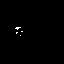

True: 7 - Predicted Class: 7


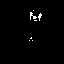

True: 8 - Predicted Class: 8


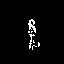

True: 9 - Predicted Class: 9


In [10]:
# CLASSIFY 10 VIDEOS
# print the images and show true and predicted class

def classify_sequence(model, frames, device):
    model.eval()

    frames_tensor = torch.tensor(frames, dtype=torch.float32).unsqueeze(1).to(device)

    with torch.no_grad():
        frames_tensor = frames_tensor.unsqueeze(0)
        outputs = model(frames_tensor)
        _, predicted = torch.max(outputs, 1)

    return predicted.item()

class_labels = {
    'walk': 0, 'run': 1, 'jump': 2, 'side': 3, 'bend': 4,
    'wave1': 5, 'wave2': 6, 'pjump': 7, 'jack': 8, 'skip': 9
}


for key in test_videos:
  test_video_transformed = randomly_transform_video(test_videos[key][0])
  test_frames = test_video_transformed
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  model.to(device)
  predicted_label = classify_sequence(model, test_frames, device)
  display_tensor_image(test_video_transformed[10])
  print(f'True: {class_labels[key]} - Predicted Class: {predicted_label}')

In [11]:
# # DOWNLOAD CURRENT MODEL
# import torch
# from google.colab import files

# path = 'save.pth'
# torch.save(model.state_dict(), path)

# files.download(path)